In [1]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('stopwords')
nltk.download('vader_lexicon')

Seed = 42
np.random.seed(Seed)

[nltk_data] Downloading package stopwords to C:\Users\TUF
[nltk_data]     GAMING\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to C:\Users\TUF
[nltk_data]     GAMING\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [2]:
Path = "C:/Users/TUF GAMING/MMU/Year 3 Sem 2/SocialMediaComp/assignment/dataset.csv"

In [3]:
df_full = pd.read_csv(Path)
print("Dataset shape:", df_full.shape)
print("Columns:", df_full.columns.tolist())

Dataset shape: (6417106, 5)
Columns: ['app_id', 'app_name', 'review_text', 'review_score', 'review_votes']


In [4]:
df_full = df_full[['app_name', 'review_text', 'review_score', 'review_votes']].dropna(
    subset=['review_text', 'review_score'])
print(df_full.columns.tolist())
print(df_full.shape)


['app_name', 'review_text', 'review_score', 'review_votes']
(6409801, 4)


In [5]:
df = df_full.sample(n=500_000, random_state=Seed).reset_index(drop=True)
print("\nCurrent Sample", df.shape)
print(df['review_score'].value_counts())


Current Sample (500000, 4)
review_score
 1    410020
-1     89980
Name: count, dtype: int64


In [6]:
# How many unique games are in our 500k sample?
# And what's the per-game sentiment breakdown?
print(f"Unique games in sample: {df['app_name'].nunique()}")
print(f"\nTop 10 most reviewed games in sample")
print(df['app_name'].value_counts().head(10))

print(f"\n(top 10 games by vol):")
top_games = df['app_name'].value_counts().head(10).index
for game in top_games:
    subset = df[df['app_name'] == game]
    pos_rate = (subset['review_score'] == 1).mean() * 100
    print(f"  {game[:40]:40s}  {pos_rate:.1f}% positive  (n={len(subset):,})")
# --- CHECK ---
print(df.shape[0], "rows", df.shape[1], "columns")


Unique games in sample: 7945

Top 10 most reviewed games in sample
app_name
PAYDAY 2              6895
DayZ                  6884
Terraria              6597
Rust                  6018
Dota 2                5669
Undertale             4223
Rocket League         4198
Left 4 Dead 2         3922
Warframe              3733
Grand Theft Auto V    3381
Name: count, dtype: int64

(top 10 games by vol):
  PAYDAY 2                                  69.9% positive  (n=6,895)
  DayZ                                      66.2% positive  (n=6,884)
  Terraria                                  96.5% positive  (n=6,597)
  Rust                                      79.8% positive  (n=6,018)
  Dota 2                                    85.9% positive  (n=5,669)
  Undertale                                 96.1% positive  (n=4,223)
  Rocket League                             94.4% positive  (n=4,198)
  Left 4 Dead 2                             92.5% positive  (n=3,922)
  Warframe                                  

## Cleaning, Labelling, EDA


In [7]:
stop_words = set(stopwords.words('english'))

def clean_review(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [w for w in text.split() if w not in stop_words and len(w) > 1]
    return ' '.join(tokens)

df['clean_text'] = df['review_text'].apply(clean_review)
print(df.shape)
df[['review_text', 'clean_text']].head()


(500000, 5)


,review_text,clean_text
0,Don't play it if you are 14 like me.It's too v...,play like violent much blood organs splatered ...
1,Early Access Review,early access review
2,Early Access Review,early access review
3,"I like the game, it's a good time waster. Thou...",like game good time waster though play daily e...
4,"A worthy sequel, already spent plenty of time ...",worthy sequel already spent plenty time really...


In [8]:
SentimentIntensityAna = SentimentIntensityAnalyzer()
df['vader_compound'] = df['clean_text'].apply(
    lambda text: SentimentIntensityAna.polarity_scores(text)['compound'])
print(df.shape)
print(df['vader_compound'].describe())


(500000, 6)
count    500000.000000
mean          0.380879
std           0.515019
min          -1.000000
25%           0.000000
50%           0.510600
75%           0.855500
max           1.000000
Name: vader_compound, dtype: float64


In [9]:
labels_dict = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

def method_a_label(row):
    score = row['review_score']
    compound = row['vader_compound']
    if score == 1 and compound >= 0.05:
        return 2
    elif score == -1 and compound <= -0.05:
        return 0
    else:
        return 1

df['label_A'] = df.apply(method_a_label, axis=1)
print(df['label_A'].value_counts().sort_index())


label_A
0     26884
1    198340
2    274776
Name: count, dtype: int64


In [10]:
def method_b_label(compound):
    if compound >= 0.05:
        return 2
    elif compound <= -0.05:
        return 0
    else:
        return 1

df['label_B'] = df['vader_compound'].apply(method_b_label)
print(df['label_B'].value_counts().sort_index())


label_B
0     68126
1    118787
2    313087
Name: count, dtype: int64


In [11]:
from sklearn.metrics import cohen_kappa_score

crosstab = pd.crosstab(df['label_A'].map(labels_dict), df['label_B'].map(labels_dict))
agreement = (df['label_A'] == df['label_B']).mean()
kappa = cohen_kappa_score(df['label_A'], df['label_B'])
print(crosstab)
print("agreement", round(agreement, 3), "kappa", round(kappa, 3))


label_B   Negative  Neutral  Positive
label_A                              
Negative     26884        0         0
Neutral      41242   118787     38311
Positive         0        0    274776
agreement 0.841 kappa 0.713


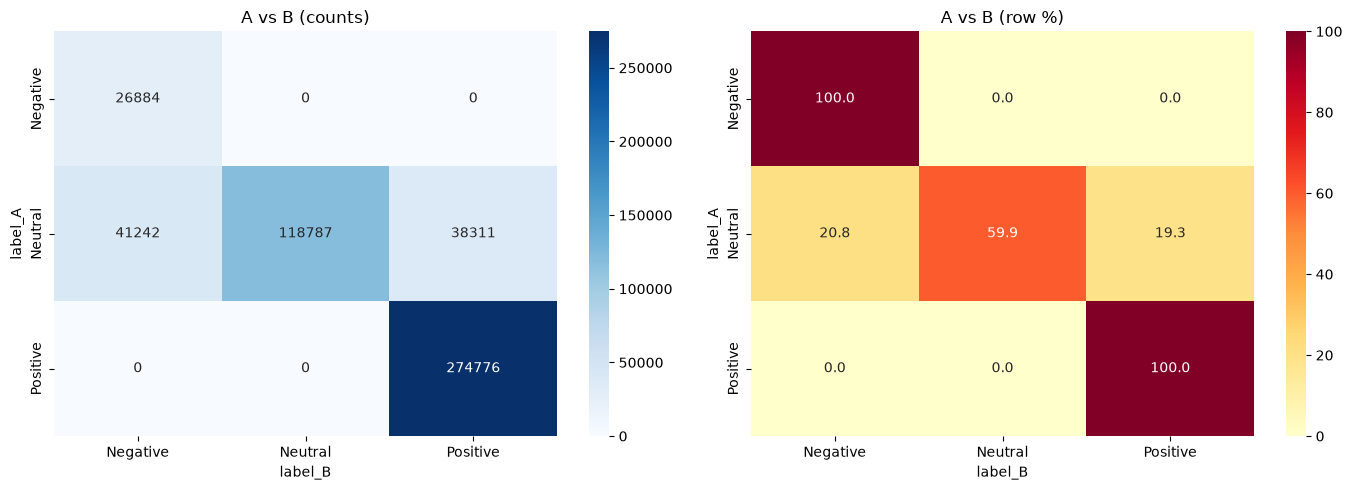

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('A vs B (counts)')
crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0) * 100
sns.heatmap(crosstab_pct, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('A vs B (row %)')
plt.tight_layout()
plt.savefig('fig_label_agreement.png', dpi=150, bbox_inches='tight')
plt.show()


In [13]:
case1 = df[(df['review_score'] == 1) & (df['label_B'] == 0)].head(3)
case2 = df[(df['review_score'] == -1) & (df['label_B'] == 2)].head(3)
print("recommended but negative text:")
for _, row in case1.iterrows():
    print(round(row['vader_compound'], 3), str(row['review_text'])[:120])
print("\nnot recommended but positive text:")
for _, row in case2.iterrows():
    print(round(row['vader_compound'], 3), str(row['review_text'])[:120])


recommended but negative text:
-0.727 hitboxes are like cs1.6 the bullets go where the cursor is \\ the cursor goes with the spray pattern and you have to 'ta
-0.919 Quake 3. Quake Live. In my opinion the best arena style multi player first person shooter at the moment. This is the the
-0.402 Just Buy it!                 Why are you still reading this, Buy the Damn thing!

not recommended but positive text:
0.802 It may not technically be pay-to-win, but like every other free-to-play game, its pay-to-avoid-endless-grinding and also
0.796 EDITED, as my previous review was a bit harsh. The issue is known f or people running integrated graphics cards, like me
0.459 Why does it keep saying 'Steam is not running' Help pls in Aura Kingdom


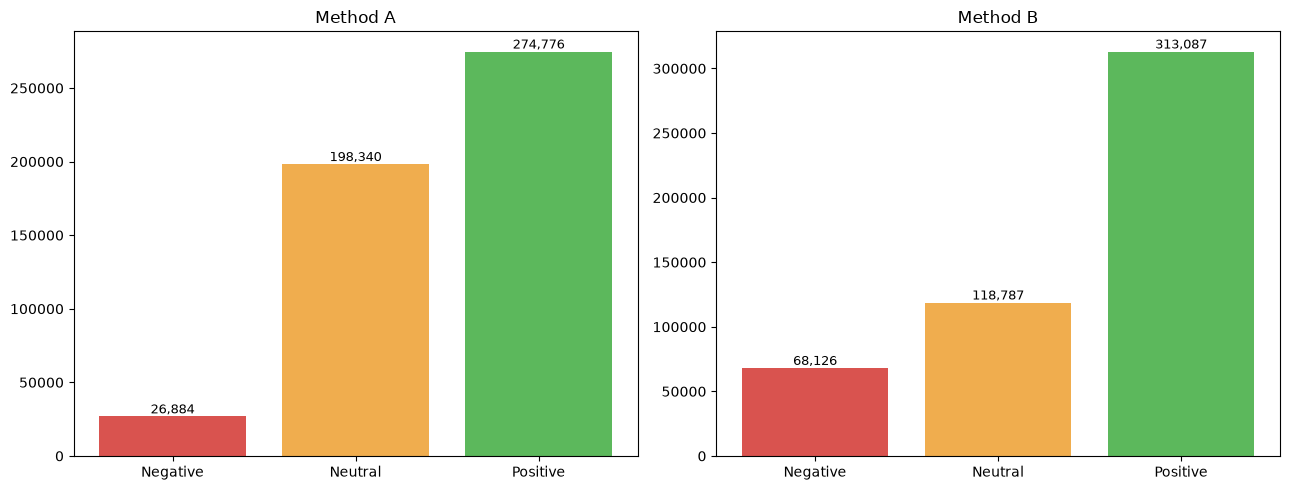

In [14]:
label_names = ['Negative', 'Neutral', 'Positive']
colors = ['#d9534f', '#f0ad4e', '#5cb85c']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, title in zip(axes, ['label_A', 'label_B'], ['Method A', 'Method B']):
    counts = df[col].value_counts().sort_index()
    ax.bar(label_names, counts.values, color=colors)
    ax.set_title(title)
    for i, v in enumerate(counts.values):
        ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('fig1_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


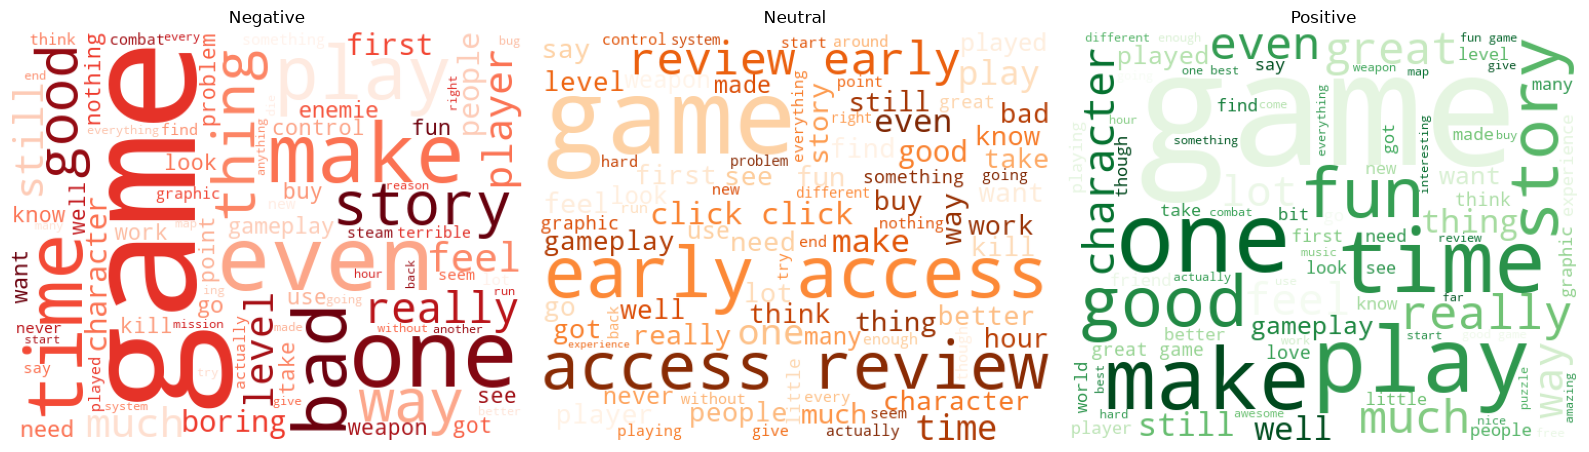

In [15]:
from wordcloud import WordCloud
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cmaps = ['Reds', 'Oranges', 'Greens']
for ax, (label_int, label_str), cmap in zip(axes, labels_dict.items(), cmaps):
    subset = df[df['label_A'] == label_int]['clean_text']
    blob = ' '.join(subset.sample(min(10_000, len(subset)), random_state=Seed).values)
    wc = WordCloud(width=500, height=400, background_color='white',
                   colormap=cmap, max_words=80).generate(blob)
    ax.imshow(wc); ax.axis('off'); ax.set_title(label_str)
plt.tight_layout()
plt.savefig('fig2_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()


(500000, 9)


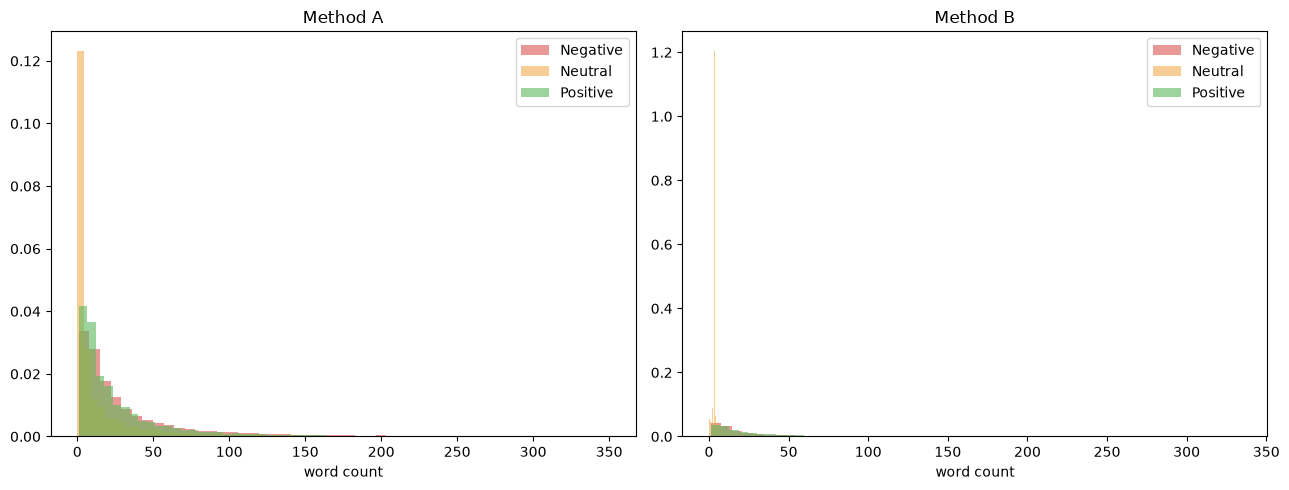

In [16]:
df['review_length'] = df['clean_text'].apply(lambda x: len(x.split()))
print(df.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, title in zip(axes, ['label_A', 'label_B'], ['Method A', 'Method B']):
    for label_int, color in zip([0, 1, 2], colors):
        s = df[df[col] == label_int]['review_length']
        cap = s.quantile(0.99)
        ax.hist(s[s <= cap], bins=50, alpha=0.6, color=color, label=labels_dict[label_int], density=True)
    ax.set_title(title); ax.set_xlabel('word count'); ax.legend()
plt.tight_layout()
plt.savefig('fig3_length_dist.png', dpi=150, bbox_inches='tight')
plt.show()


In [17]:
before = len(df)
df = df[df['clean_text'].str.strip() != ''].reset_index(drop=True)
print("removed", before - len(df), "-> rows", len(df))
print(df.columns.tolist())
df.to_csv('steam_phase1.csv', index=False)


removed 3868 -> rows 496132
['app_name', 'review_text', 'review_score', 'review_votes', 'clean_text', 'vader_compound', 'label_A', 'label_B', 'review_length']


In [18]:
df = pd.read_csv('steam_phase1.csv')
print(df.shape)
print(df['label_A'].value_counts().sort_index())


(496132, 9)
label_A
0     26884
1    194472
2    274776
Name: count, dtype: int64


## Classical ML VADER, TF-IDF, LogReg, SVM, RF


In [19]:
from sklearn.model_selection import train_test_split

X = df['clean_text'].fillna('')
y = df['label_A']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=Seed, stratify=y)
print(X_train.shape, X_test.shape)


(396905,) (99227,)


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=3, sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print(X_train_tfidf.shape, X_test_tfidf.shape)


(396905, 5000) (99227, 5000)


In [21]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

results = {}

def evaluate(name, y_true, y_pred):
    macro = f1_score(y_true, y_pred, average='macro')
    results[name] = macro
    print(name, "macro-f1", round(macro, 3))
    print(classification_report(y_true, y_pred, target_names=label_names))


In [22]:
# VADER baseline: map the precomputed compound on the test rows
test_compound = df.loc[X_test.index, 'vader_compound']
vader_pred = test_compound.apply(method_b_label)
evaluate('VADER', y_test, vader_pred)


VADER macro-f1 0.748
              precision    recall  f1-score   support

    Negative       0.39      1.00      0.56      5377
     Neutral       1.00      0.59      0.74     38895
    Positive       0.88      1.00      0.94     54955

    accuracy                           0.84     99227
   macro avg       0.76      0.86      0.75     99227
weighted avg       0.90      0.84      0.84     99227



Note on the VADER baseline. Method A labels are partly derived from VADER's compound score, so evaluating VADER against label_A is circular thus this is why its recall looks unusually high. The fair comparison is between the trained models (LogReg, SVM, RF, DistilBERT), which learn from TF-IDF / tokens independently.

In [23]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000, C=1.0)
logreg.fit(X_train_tfidf, y_train)
logreg_pred = logreg.predict(X_test_tfidf)
evaluate('LogReg', y_test, logreg_pred)


LogReg macro-f1 0.766
              precision    recall  f1-score   support

    Negative       0.72      0.44      0.55      5377
     Neutral       0.83      0.84      0.84     38895
    Positive       0.90      0.93      0.92     54955

    accuracy                           0.87     99227
   macro avg       0.82      0.74      0.77     99227
weighted avg       0.86      0.87      0.86     99227



In [24]:
from sklearn.svm import LinearSVC

svm = LinearSVC(C=1.0, dual=False)
svm.fit(X_train_tfidf, y_train)
svm_pred = svm.predict(X_test_tfidf)
evaluate('SVM', y_test, svm_pred)


SVM macro-f1 0.743
              precision    recall  f1-score   support

    Negative       0.68      0.39      0.49      5377
     Neutral       0.83      0.82      0.82     38895
    Positive       0.89      0.94      0.91     54955

    accuracy                           0.86     99227
   macro avg       0.80      0.71      0.74     99227
weighted avg       0.86      0.86      0.86     99227



C:\Users\Public\anaconda3\envs\smc-gpu\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [25]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=Seed)
rf.fit(X_train_tfidf, y_train)
rf_pred = rf.predict(X_test_tfidf)
evaluate('RandomForest', y_test, rf_pred)


RandomForest macro-f1 0.689
              precision    recall  f1-score   support

    Negative       0.72      0.27      0.39      5377
     Neutral       0.88      0.71      0.79     38895
    Positive       0.81      0.97      0.89     54955

    accuracy                           0.83     99227
   macro avg       0.81      0.65      0.69     99227
weighted avg       0.84      0.83      0.82     99227



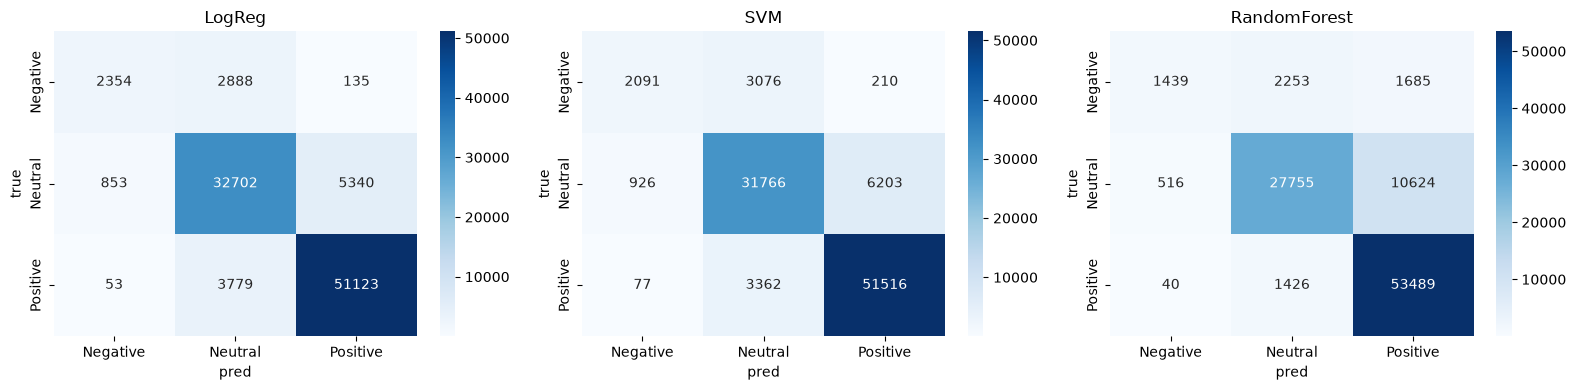

In [26]:
preds = {'LogReg': logreg_pred, 'SVM': svm_pred, 'RandomForest': rf_pred}
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, pred) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=label_names, yticklabels=label_names)
    ax.set_title(name); ax.set_xlabel('pred'); ax.set_ylabel('true')
plt.tight_layout()
plt.savefig('fig_phase2_confusion.png', dpi=150, bbox_inches='tight')
plt.show()


In [27]:
feature_names = tfidf.get_feature_names_out()
for i, cls in labels_dict.items():
    top = logreg.coef_[i].argsort()[-12:][::-1]
    print(cls, [feature_names[j] for j in top])


Negative ['worst', 'horrible', 'boring', 'terrible', 'awful', 'bad', 'worse', 'poor', 'disappointing', 'broken', 'dead', 'ruined']
Neutral ['access review', 'murder', 'brutal', 'devil', 'save money', 'kill', 'pay win', 'killing', 'violent', 'violence', 'wanted like', 'early access']
Positive ['best', 'great', 'love', 'fun', 'amazing', 'awesome', 'good', 'beautiful', 'fantastic', 'excellent', 'like', 'perfect']


LogReg          0.765783
VADER           0.747548
SVM             0.743480
RandomForest    0.688537
dtype: float64


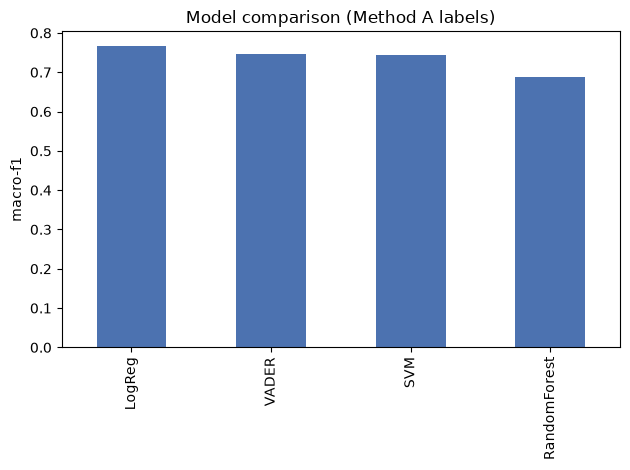

In [28]:
comp = pd.Series(results).sort_values(ascending=False)
print(comp)
comp.plot(kind='bar', color='#4c72b0')
plt.ylabel('macro-f1'); plt.title('Model comparison (Method A labels)')
plt.tight_layout()
plt.savefig('fig_phase2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [29]:
out = df.loc[X_test.index, ['review_text', 'clean_text', 'label_A']].copy()
out['logreg_pred'] = logreg_pred
out['svm_pred'] = svm_pred
out['rf_pred'] = rf_pred
out.to_csv('steam_phase2_predictions.csv', index=False)
print(out.shape)


(99227, 6)


## DistilBERT (transformer)


In [30]:
import torch
from transformers import (DistilBertTokenizerFast, DistilBertForSequenceClassification,
                          Trainer, TrainingArguments, DataCollatorWithPadding)
from datasets import Dataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))


C:\Users\Public\anaconda3\envs\smc-gpu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda
NVIDIA GeForce RTX 5050 Laptop GPU


In [31]:
print(df.columns.tolist())
print(df.shape)

['app_name', 'review_text', 'review_score', 'review_votes', 'clean_text', 'vader_compound', 'label_A', 'label_B', 'review_length']
(496132, 9)


In [32]:
import sys
import torch

print(sys.executable)
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

C:\Users\Public\anaconda3\envs\smc-gpu\python.exe
2.11.0+cu128
12.8
True
NVIDIA GeForce RTX 5050 Laptop GPU


In [34]:
df = pd.read_csv('steam_phase1.csv')
print(df.shape)
print(df['label_A'].value_counts().sort_index())

# DistilBERT is heavy; train on a stratified subsample for feasible GPU time
parts = []
for label in sorted(df['label_A'].unique()):
    g = df[df['label_A'] == label]
    parts.append(g.sample(min(50000, len(g)), random_state=Seed))

sample = pd.concat(parts).reset_index(drop=True)
print(sample.columns.tolist())
print(sample['label_A'].value_counts().sort_index())


(496132, 9)
label_A
0     26884
1    194472
2    274776
Name: count, dtype: int64
['app_name', 'review_text', 'review_score', 'review_votes', 'clean_text', 'vader_compound', 'label_A', 'label_B', 'review_length']
label_A
0    26884
1    50000
2    50000
Name: count, dtype: int64


In [35]:
from sklearn.model_selection import train_test_split

bert_train, bert_test = train_test_split(
    sample, test_size=0.2, random_state=Seed, stratify=sample['label_A'])
print(bert_train.shape, bert_test.shape)


(101507, 9) (25377, 9)


In [36]:
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

def to_dataset(frame):
    ds = Dataset.from_dict({'text': frame['clean_text'].astype(str).tolist(),
                            'label': frame['label_A'].tolist()})
    ds = ds.map(lambda b: tokenizer(b['text'], truncation=True, max_length=256), batched=True)
    return ds

train_ds = to_dataset(bert_train)
test_ds = to_dataset(bert_test)
print(train_ds)


Map: 100%|██████████| 25377/25377 [00:00<00:00, 40158.66 examples/s]

Dataset({
    features: ['text', 'label', 'input_ids', 'attention_mask'],
    num_rows: 101507
})


In [37]:
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=3).to(device)


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3394.19it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [38]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    return {'macro_f1': f1_score(labels, preds, average='macro')}


In [40]:
collator = DataCollatorWithPadding(tokenizer)

args = TrainingArguments(
    output_dir='bert_out',
    learning_rate=3e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=4,
    weight_decay=0.01,
    eval_strategy='epoch',
    fp16=(device.type == 'cuda'),
    report_to='none')

trainer = Trainer(model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    data_collator=collator,
    compute_metrics=compute_metrics)


In [41]:
trainer.train()


Epoch,Training Loss,Validation Loss,Macro F1
1,0.343485,0.350071,0.842529
2,0.264982,0.312340,0.869228
3,0.185785,0.336258,0.875083
4,0.129372,0.406110,0.872855


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  6.37it/s]


TrainOutput(global_step=12692, training_loss=0.2436737530320892, metrics={'train_runtime': 1763.3209, 'train_samples_per_second': 230.263, 'train_steps_per_second': 7.198, 'total_flos': 2.1104754774161148e+16, 'train_loss': 0.2436737530320892, 'epoch': 4.0})

In [42]:
pred = trainer.predict(test_ds)
bert_pred = pred.predictions.argmax(-1)
evaluate('DistilBERT', bert_test['label_A'].values, bert_pred)


DistilBERT macro-f1 0.873
              precision    recall  f1-score   support

    Negative       0.86      0.86      0.86      5377
     Neutral       0.85      0.84      0.84     10000
    Positive       0.91      0.92      0.91     10000

    accuracy                           0.88     25377
   macro avg       0.87      0.87      0.87     25377
weighted avg       0.88      0.88      0.88     25377



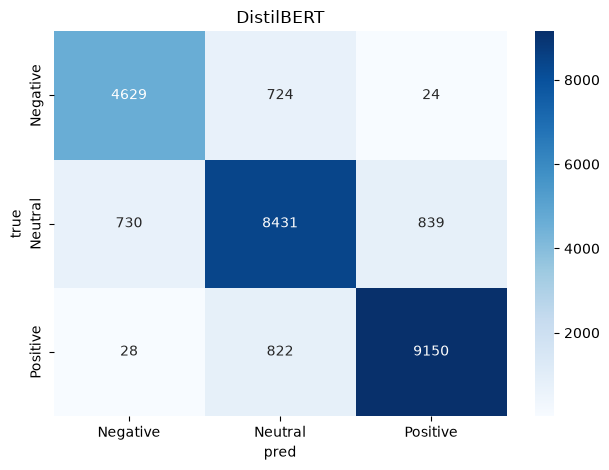

In [43]:
cm = confusion_matrix(bert_test['label_A'].values, bert_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('DistilBERT'); plt.xlabel('pred'); plt.ylabel('true')
plt.tight_layout()
plt.savefig('fig_phase3_bert_cm.png', dpi=150, bbox_inches='tight')
plt.show()


DistilBERT      0.872855
LogReg          0.765783
VADER           0.747548
SVM             0.743480
RandomForest    0.688537
dtype: float64


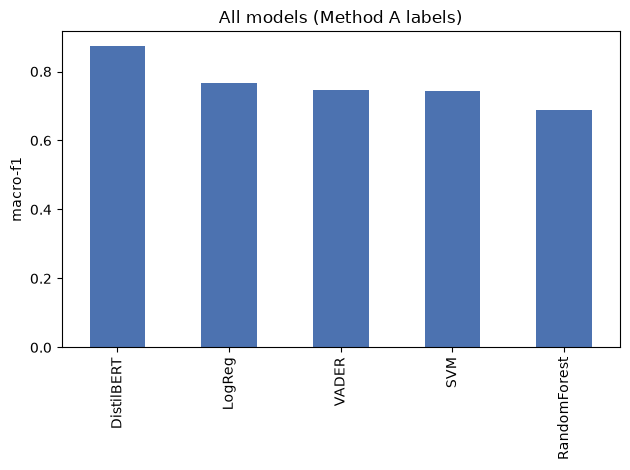

In [44]:
comp = pd.Series(results).sort_values(ascending=False)
print(comp)
comp.plot(kind='bar', color='#4c72b0')
plt.ylabel('macro-f1'); plt.title('All models (Method A labels)')
plt.tight_layout()
plt.savefig('fig_phase3_allmodels.png', dpi=150, bbox_inches='tight')
plt.show()


In [46]:
import subprocess
subprocess.run(['python', '-m', 'spacy', 'download', 'en_core_web_sm'], check=True)

CompletedProcess(args=['python', '-m', 'spacy', 'download', 'en_core_web_sm'], returncode=0)

##  Aspect-Based Sentiment Analysis (ABSA)

In [47]:
import spacy
from collections import Counter, defaultdict

nlp = spacy.load('en_core_web_sm', disable=['ner'])

# ABSA is CPU-heavy; sample raw reviews
absa_sample = df.sample(50000, random_state=Seed)
print(absa_sample.shape)


(50000, 9)


In [48]:
aspect_counts = Counter()
aspect_sent = defaultdict(list)

for text in absa_sample['review_text'].astype(str):
    doc = nlp(text)
    for token in doc:
        if token.pos_ in ('NOUN', 'PROPN'):
            mods = [c.text for c in token.children if c.pos_ == 'ADJ']
            phrase = ' '.join(mods + [token.text])
            comp = SentimentIntensityAna.polarity_scores(phrase)['compound']
            aspect_counts[token.lemma_.lower()] += 1
            aspect_sent[token.lemma_.lower()].append(comp)

print(aspect_counts.most_common(10))


[('game', 73830), ('♥', 19761), ('review', 10394), ('time', 9880), ('access', 8337), ('early', 8048), ('story', 7448), ('fun', 5236), ('thing', 5144), ('hour', 4702)]


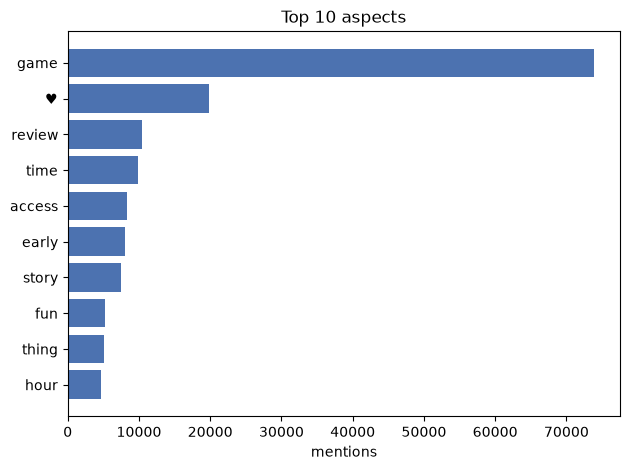

In [49]:
top = aspect_counts.most_common(10)
names = [a for a, _ in top]
vals = [c for _, c in top]
plt.barh(names[::-1], vals[::-1], color='#4c72b0')
plt.xlabel('mentions'); plt.title('Top 10 aspects')
plt.tight_layout()
plt.savefig('fig_phase3_aspects.png', dpi=150, bbox_inches='tight')
plt.show()


In [50]:
rows = []
for aspect, _ in aspect_counts.most_common(10):
    scores = aspect_sent[aspect]
    pos = np.mean([s >= 0.05 for s in scores]) * 100
    neg = np.mean([s <= -0.05 for s in scores]) * 100
    neu = 100 - pos - neg
    rows.append([aspect, len(scores), round(pos, 1), round(neu, 1), round(neg, 1)])

absa_df = pd.DataFrame(rows, columns=['aspect', 'mentions', 'pos%', 'neu%', 'neg%'])
print(absa_df)
absa_df.to_csv('steam_phase3_absa.csv', index=False)


   aspect  mentions  pos%   neu%  neg%
0    game     73830  15.0   83.7   1.3
1       ♥     19761   0.2   99.5   0.3
2  review     10394   1.9   95.2   2.9
3    time      9880   4.0   94.5   1.5
4  access      8337   0.1   99.9   0.0
5   early      8048   0.0  100.0   0.0
6   story      7448  15.1   83.5   1.4
7     fun      5236  99.5    0.3   0.2
8   thing      5144  11.1   81.5   7.4
9    hour      4702   2.1   97.5   0.5


In [51]:
# the heart symbol and other non-letters leaked in as aspects, strip them first
def clean_for_absa(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'[^a-zA-Z\s.!?]', ' ', text)   # keep letters + basic punctuation for spacy
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# nouns that are not real opinion targets for games
skip = {'game', 'games', 'thing', 'things', 'review', 'time', 'access', 'early',
        'hour', 'hours', 'lot', 'bit', 'way', 'people', 'someone', 'everyone',
        'something', 'anything', 'nothing', 'day', 'days', 'year', 'years'}

In [52]:
aspect_counts = Counter()
aspect_sent = defaultdict(list)

for text in absa_sample['review_text'].astype(str):
    doc = nlp(clean_for_absa(text))
    for token in doc:
        if token.pos_ in ('NOUN', 'PROPN'):
            word = token.lemma_.lower()
            if word in skip or len(word) < 3:
                continue
            mods = [c.text for c in token.children if c.pos_ == 'ADJ']
            phrase = ' '.join(mods + [token.text])
            comp = SentimentIntensityAna.polarity_scores(phrase)['compound']
            aspect_counts[word] += 1
            aspect_sent[word].append(comp)

print(aspect_counts.most_common(15))


[('story', 7495), ('fun', 5327), ('don', 5080), ('character', 4586), ('gameplay', 4440), ('player', 3494), ('level', 3348), ('graphic', 3221), ('friend', 2707), ('world', 2634), ('enemy', 2470), ('weapon', 2367), ('system', 2347), ('money', 2334), ('one', 2310)]


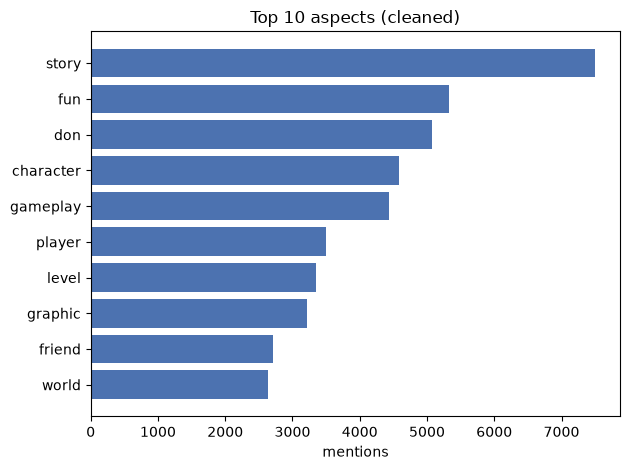

In [53]:
top = aspect_counts.most_common(10)
names = [a for a, _ in top]
vals = [c for _, c in top]
plt.barh(names[::-1], vals[::-1], color='#4c72b0')
plt.xlabel('mentions'); plt.title('Top 10 aspects (cleaned)')
plt.tight_layout()
plt.savefig('fig_phase3_aspects_v2.png', dpi=150, bbox_inches='tight')
plt.show()


In [54]:
rows = []
for aspect, _ in aspect_counts.most_common(10):
    scores = aspect_sent[aspect]
    pos = np.mean([s >= 0.05 for s in scores]) * 100
    neg = np.mean([s <= -0.05 for s in scores]) * 100
    neu = 100 - pos - neg
    rows.append([aspect, len(scores), round(pos, 1), round(neu, 1), round(neg, 1)])

absa_df = pd.DataFrame(rows, columns=['aspect', 'mentions', 'pos%', 'neu%', 'neg%'])
print(absa_df)
absa_df.to_csv('steam_phase3_absa.csv', index=False)


      aspect  mentions  pos%   neu%  neg%
0      story      7495  14.9   83.6   1.5
1        fun      5327  99.5    0.2   0.2
2        don      5080   0.0  100.0   0.0
3  character      4586   7.0   91.6   1.4
4   gameplay      4440  11.8   86.1   2.1
5     player      3494   5.2   93.3   1.4
6      level      3348   5.0   92.5   2.5
7    graphic      3221  20.0   77.4   2.6
8     friend      2707  99.7    0.1   0.2
9      world      2634   4.6   93.4   1.9


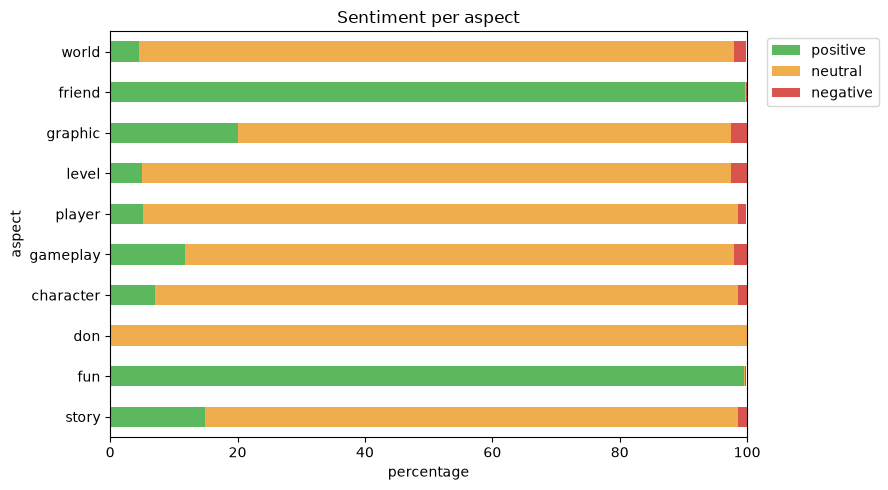

In [55]:
absa_df.set_index('aspect')[['pos%', 'neu%', 'neg%']].plot(
    kind='barh', stacked=True, figsize=(9, 5),
    color=['#5cb85c', '#f0ad4e', '#d9534f'])
plt.xlabel('percentage'); plt.title('Sentiment per aspect')
plt.legend(['positive', 'neutral', 'negative'], bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.savefig('fig_phase3_aspect_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()


In [56]:
skip = {'game', 'games', 'thing', 'things', 'review', 'time', 'access', 'early',
        'hour', 'hours', 'lot', 'bit', 'way', 'people', 'someone', 'everyone',
        'something', 'anything', 'nothing', 'day', 'days', 'year', 'years',
        'don', 'doesn', 'didn', 'isn', 'wasn', 'll', 've', 're', 'one'}

In [57]:
aspect_counts2 = Counter()
aspect_sent2 = defaultdict(list)

for text in absa_sample['review_text'].astype(str):
    doc = nlp(clean_for_absa(text))
    for token in doc:
        if token.pos_ in ('NOUN', 'PROPN'):
            word = token.lemma_.lower()
            if word in skip or len(word) < 3:
                continue
            mods = [c.text for c in token.children if c.pos_ == 'ADJ']
            phrase = ' '.join(mods + [token.text])
            comp = SentimentIntensityAna.polarity_scores(phrase)['compound']
            aspect_counts2[word] += 1
            aspect_sent2[word].append(comp)

print(aspect_counts2.most_common(15))

[('story', 7495), ('fun', 5327), ('character', 4586), ('gameplay', 4440), ('player', 3494), ('level', 3348), ('graphic', 3221), ('friend', 2707), ('world', 2634), ('enemy', 2470), ('weapon', 2367), ('system', 2347), ('money', 2334), ('combat', 2147), ('experience', 2143)]


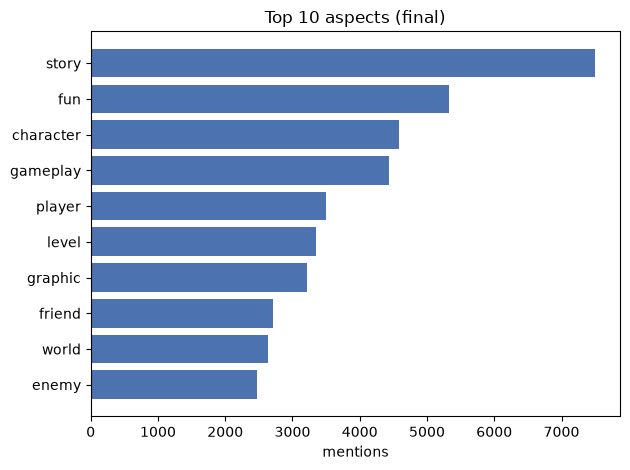

In [58]:
top2 = aspect_counts2.most_common(10)
names2 = [a for a, _ in top2]
vals2 = [c for _, c in top2]
plt.barh(names2[::-1], vals2[::-1], color='#4c72b0')
plt.xlabel('mentions'); plt.title('Top 10 aspects (final)')
plt.tight_layout()
plt.savefig('fig_absa_final_counts.png', dpi=150, bbox_inches='tight')
plt.show()

In [59]:
rows2 = []
for aspect, _ in aspect_counts2.most_common(10):
    scores = aspect_sent2[aspect]
    pos = np.mean([s >= 0.05 for s in scores]) * 100
    neg = np.mean([s <= -0.05 for s in scores]) * 100
    neu = 100 - pos - neg
    rows2.append([aspect, len(scores), round(pos,1), round(neu,1), round(neg,1)])

absa_df2 = pd.DataFrame(rows2, columns=['aspect','mentions','pos%','neu%','neg%'])
print(absa_df2)
absa_df2.to_csv('steam_phase3_absa_final.csv', index=False)

      aspect  mentions  pos%  neu%  neg%
0      story      7495  14.9  83.6   1.5
1        fun      5327  99.5   0.2   0.2
2  character      4586   7.0  91.6   1.4
3   gameplay      4440  11.8  86.1   2.1
4     player      3494   5.2  93.3   1.4
5      level      3348   5.0  92.5   2.5
6    graphic      3221  20.0  77.4   2.6
7     friend      2707  99.7   0.1   0.2
8      world      2634   4.6  93.4   1.9
9      enemy      2470   0.2   0.0  99.8


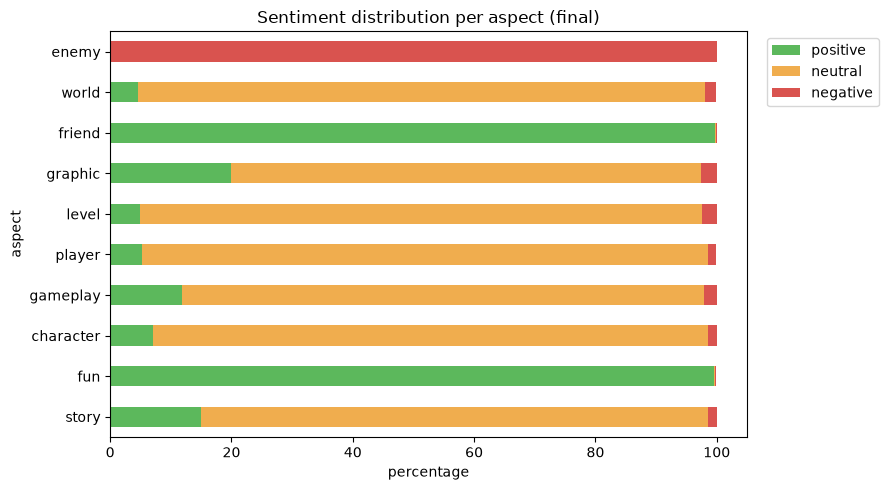

In [60]:
absa_df2.set_index('aspect')[['pos%','neu%','neg%']].plot(
    kind='barh', stacked=True, figsize=(9,5),
    color=['#5cb85c','#f0ad4e','#d9534f'])
plt.xlabel('percentage'); plt.title('Sentiment distribution per aspect (final)')
plt.legend(['positive','neutral','negative'], bbox_to_anchor=(1.02,1))
plt.tight_layout()
plt.savefig('fig_absa_final_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

## ABSA with DistilBERT
VADER scores aspect phrases by word valence only (it marks 'enemy' negative even when neutral in games). Rescore the same phrases with the trained DistilBERT to see if context helps.

In [61]:
# return 0/1/2
def bert_label_phrase(phrases):
    enc = tokenizer(phrases, truncation=True, max_length=32,
                    padding=True, return_tensors='pt').to(device)
    model.eval()
    with torch.no_grad():
        logits = model(**enc).logits
    return logits.argmax(-1).cpu().numpy()


In [62]:
# list of phrases (reuse the cleaned text + skip set)
aspect_phrases = defaultdict(list)

for text in absa_sample['review_text'].astype(str):
    doc = nlp(clean_for_absa(text))
    for token in doc:
        if token.pos_ in ('NOUN', 'PROPN'):
            word = token.lemma_.lower()
            if word in skip or len(word) < 3:
                continue
            mods = [c.text for c in token.children if c.pos_ == 'ADJ']
            phrase = ' '.join(mods + [token.text])
            aspect_phrases[word].append(phrase)

print(len(aspect_phrases), 'unique aspects')


31862 unique aspects


In [63]:
rows_bert = []
for aspect, _ in aspect_counts2.most_common(10):
    phrases = aspect_phrases[aspect]
    preds = bert_label_phrase(phrases)
    pos = np.mean(preds == 2) * 100
    neu = np.mean(preds == 1) * 100
    neg = np.mean(preds == 0) * 100
    rows_bert.append([aspect, len(phrases), round(pos,1), round(neu,1), round(neg,1)])

bert_absa_df = pd.DataFrame(rows_bert, columns=['aspect','mentions','pos%','neu%','neg%'])
print(bert_absa_df)
bert_absa_df.to_csv('steam_absa_bert.csv', index=False)


      aspect  mentions  pos%  neu%  neg%
0      story      7495  15.0  83.9   1.1
1        fun      5327  98.9   1.1   0.0
2  character      4586   6.7  92.3   1.0
3   gameplay      4440  11.6  86.6   1.9
4     player      3494   4.4  94.5   1.1
5      level      3348   4.0  93.5   2.5
6    graphic      3221  19.8  77.8   2.4
7     friend      2707  99.4   0.5   0.1
8      world      2634   4.4  95.2   0.4
9      enemy      2470   0.2  97.7   2.1


In [64]:
# compare the two methods on the aspects where they differ most
compare = absa_df2[['aspect','neg%']].merge(
    bert_absa_df[['aspect','neg%']], on='aspect', suffixes=('_vader','_bert'))
print(compare)


      aspect  neg%_vader  neg%_bert
0      story         1.5        1.1
1        fun         0.2        0.0
2  character         1.4        1.0
3   gameplay         2.1        1.9
4     player         1.4        1.1
5      level         2.5        2.5
6    graphic         2.6        2.4
7     friend         0.2        0.1
8      world         1.9        0.4
9      enemy        99.8        2.1


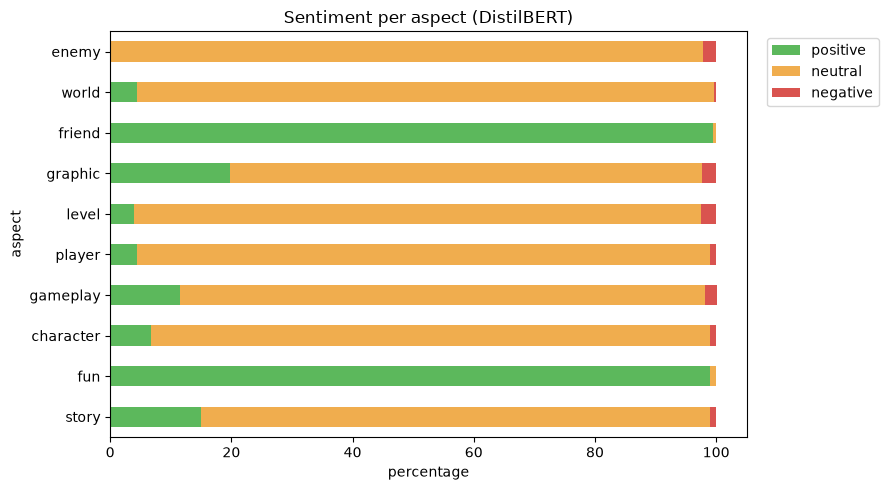

In [65]:
bert_absa_df.set_index('aspect')[['pos%','neu%','neg%']].plot(
    kind='barh', stacked=True, figsize=(9,5),
    color=['#5cb85c','#f0ad4e','#d9534f'])
plt.xlabel('percentage'); plt.title('Sentiment per aspect (DistilBERT)')
plt.legend(['positive','neutral','negative'], bbox_to_anchor=(1.02,1))
plt.tight_layout()
plt.savefig('fig_absa_bert_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()


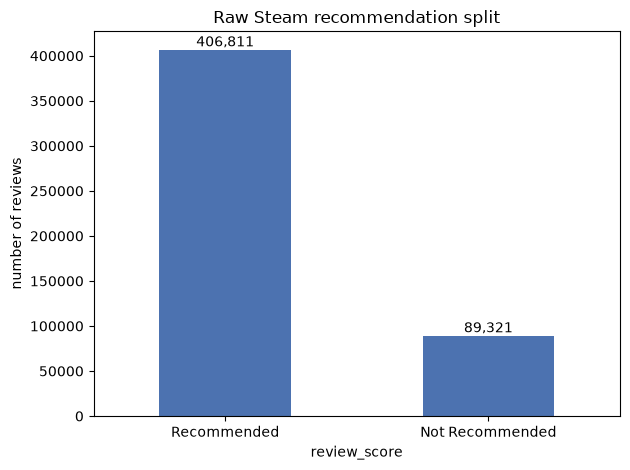

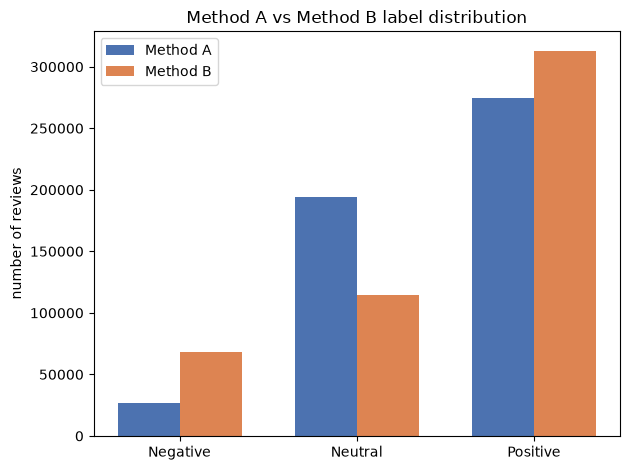

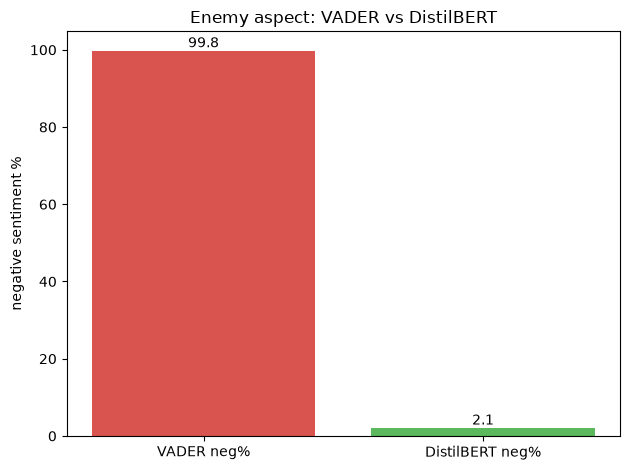

In [67]:
# ---- extra figures for the report ----
import matplotlib.pyplot as plt

# Fig 4.2 — raw recommendation split
ax = df['review_score'].map({1:'Recommended', -1:'Not Recommended'}).value_counts().plot(
    kind='bar', color='#4c72b0')
plt.ylabel('number of reviews'); plt.title('Raw Steam recommendation split')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.xticks(rotation=0); plt.tight_layout()
plt.savefig('fig_raw_split.png', dpi=150, bbox_inches='tight'); plt.show()

# Fig 4.3 — Method A vs Method B label distribution
import numpy as np
a = df['label_A'].value_counts().sort_index()
b = df['label_B'].value_counts().sort_index()
names = ['Negative','Neutral','Positive']
x = np.arange(3); w = 0.35
plt.bar(x-w/2, a.values, w, label='Method A', color='#4c72b0')
plt.bar(x+w/2, b.values, w, label='Method B', color='#dd8452')
plt.xticks(x, names); plt.ylabel('number of reviews')
plt.title('Method A vs Method B label distribution'); plt.legend()
plt.tight_layout()
plt.savefig('fig_label_methods.png', dpi=150, bbox_inches='tight'); plt.show()

# Fig 7.1 — enemy aspect: VADER vs DistilBERT negative %
enemy = compare[compare['aspect']=='enemy'].iloc[0]
plt.bar(['VADER neg%','DistilBERT neg%'],
        [enemy['neg%_vader'], enemy['neg%_bert']],
        color=['#d9534f','#5cb85c'])
plt.ylabel('negative sentiment %'); plt.title('Enemy aspect: VADER vs DistilBERT')
for i, v in enumerate([enemy['neg%_vader'], enemy['neg%_bert']]):
    plt.text(i, v, f'{v}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig('fig_enemy_compare.png', dpi=150, bbox_inches='tight'); plt.show()

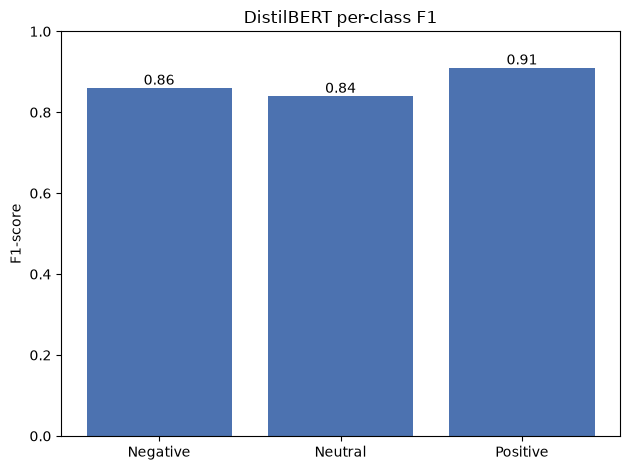

In [68]:
# Fig 6.1 — DistilBERT per-class F1
import matplotlib.pyplot as plt
f1s = [0.86, 0.84, 0.91]  # neg, neu, pos from the classification report
bars = plt.bar(['Negative','Neutral','Positive'], f1s, color='#4c72b0')
plt.ylabel('F1-score'); plt.ylim(0,1); plt.title('DistilBERT per-class F1')
for b, v in zip(bars, f1s):
    plt.text(b.get_x()+b.get_width()/2, v, f'{v}', ha='center', va='bottom')
plt.tight_layout(); plt.savefig('fig_bert_perclass_f1.png', dpi=150, bbox_inches='tight'); plt.show()